In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, ConfusionMatrixDisplay
)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


In [2]:
# Load cleaned data
df = pd.read_csv('../data/cleaned_data.csv')

print(f"✅ Data loaded: {df.shape}")
df.head()

✅ Data loaded: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [3]:
# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Features (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")
print(f"\nFeature names:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2}. {col}")

Features (X) shape : (7043, 19)
Target   (y) shape : (7043,)

Feature names:
   1. gender
   2. SeniorCitizen
   3. Partner
   4. Dependents
   5. tenure
   6. PhoneService
   7. MultipleLines
   8. InternetService
   9. OnlineSecurity
  10. OnlineBackup
  11. DeviceProtection
  12. TechSupport
  13. StreamingTV
  14. StreamingMovies
  15. Contract
  16. PaperlessBilling
  17. PaymentMethod
  18. MonthlyCharges
  19. TotalCharges


In [4]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✅ Train-Test Split Done!")
print(f"  Training samples   : {X_train.shape[0]}")
print(f"  Test samples       : {X_test.shape[0]}")
print(f"\n  Train churn rate   : {y_train.mean()*100:.1f}%")
print(f"  Test churn rate    : {y_test.mean()*100:.1f}%")

✅ Train-Test Split Done!
  Training samples   : 5634
  Test samples       : 1409

  Train churn rate   : 26.5%
  Test churn rate    : 26.5%


In [5]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature Scaling Done!")
print(f"  Mean of features (should be ~0): {X_train_scaled.mean():.4f}")
print(f"  Std of features  (should be ~1): {X_train_scaled.std():.4f}")

✅ Feature Scaling Done!
  Mean of features (should be ~0): -0.0000
  Std of features  (should be ~1): 1.0000


In [6]:
# MODEL 1: LOGISTIC REGRESSION
print("🤖 Training Logistic Regression...")
print("=" * 40)

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f"  Accuracy  : {accuracy_score(y_test, lr_pred):.4f}")
print(f"  Precision : {precision_score(y_test, lr_pred):.4f}")
print(f"  Recall    : {recall_score(y_test, lr_pred):.4f}")
print(f"  F1-Score  : {f1_score(y_test, lr_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, lr_pred_proba):.4f}")

print("\n✅ Logistic Regression trained!")

🤖 Training Logistic Regression...
  Accuracy  : 0.7991
  Precision : 0.6426
  Recall    : 0.5481
  F1-Score  : 0.5916
  ROC-AUC   : 0.8403

✅ Logistic Regression trained!


In [7]:
# MODEL 2: XGBOOST
print("🤖 Training XGBoost...")
print("=" * 40)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test_scaled)
xgb_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

print(f"  Accuracy  : {accuracy_score(y_test, xgb_pred):.4f}")
print(f"  Precision : {precision_score(y_test, xgb_pred):.4f}")
print(f"  Recall    : {recall_score(y_test, xgb_pred):.4f}")
print(f"  F1-Score  : {f1_score(y_test, xgb_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, xgb_pred_proba):.4f}")

print("\n✅ XGBoost trained!")

🤖 Training XGBoost...
  Accuracy  : 0.8006
  Precision : 0.6545
  Recall    : 0.5267
  F1-Score  : 0.5837
  ROC-AUC   : 0.8404

✅ XGBoost trained!


In [8]:
# MODEL COMPARISON TABLE
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Accuracy':  [accuracy_score(y_test, lr_pred),  accuracy_score(y_test, xgb_pred)],
    'Precision': [precision_score(y_test, lr_pred), precision_score(y_test, xgb_pred)],
    'Recall':    [recall_score(y_test, lr_pred),    recall_score(y_test, xgb_pred)],
    'F1-Score':  [f1_score(y_test, lr_pred),        f1_score(y_test, xgb_pred)],
    'ROC-AUC':   [roc_auc_score(y_test, lr_pred_proba), roc_auc_score(y_test, xgb_pred_proba)]
})

results = results.round(4)

print("=" * 70)
print("📊 MODEL COMPARISON")
print("=" * 70)
print(results.to_string(index=False))

best_idx = results['F1-Score'].idxmax()
best_model_name = results.loc[best_idx, 'Model']
print(f"\n🏆 Best Model: {best_model_name}")
results

📊 MODEL COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7991     0.6426  0.5481    0.5916   0.8403
            XGBoost    0.8006     0.6545  0.5267    0.5837   0.8404

🏆 Best Model: Logistic Regression


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7991,0.6426,0.5481,0.5916,0.8403
1,XGBoost,0.8006,0.6545,0.5267,0.5837,0.8404


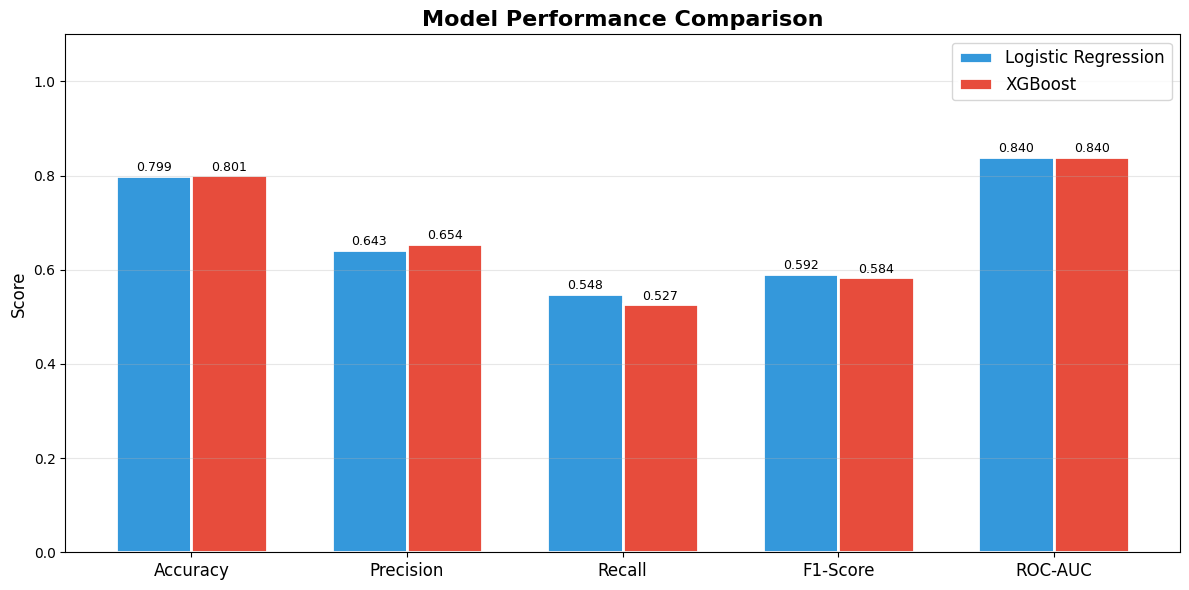

✅ Plot saved!


In [9]:
# PLOT: Model Comparison Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.35

lr_values = results[results['Model'] == 'Logistic Regression'][metrics].values[0]
xgb_values = results[results['Model'] == 'XGBoost'][metrics].values[0]

bars1 = ax.bar(x - width/2, lr_values, width, label='Logistic Regression',
               color='#3498db', edgecolor='white', linewidth=2)
bars2 = ax.bar(x + width/2, xgb_values, width, label='XGBoost',
               color='#e74c3c', edgecolor='white', linewidth=2)

ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../src/images/08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

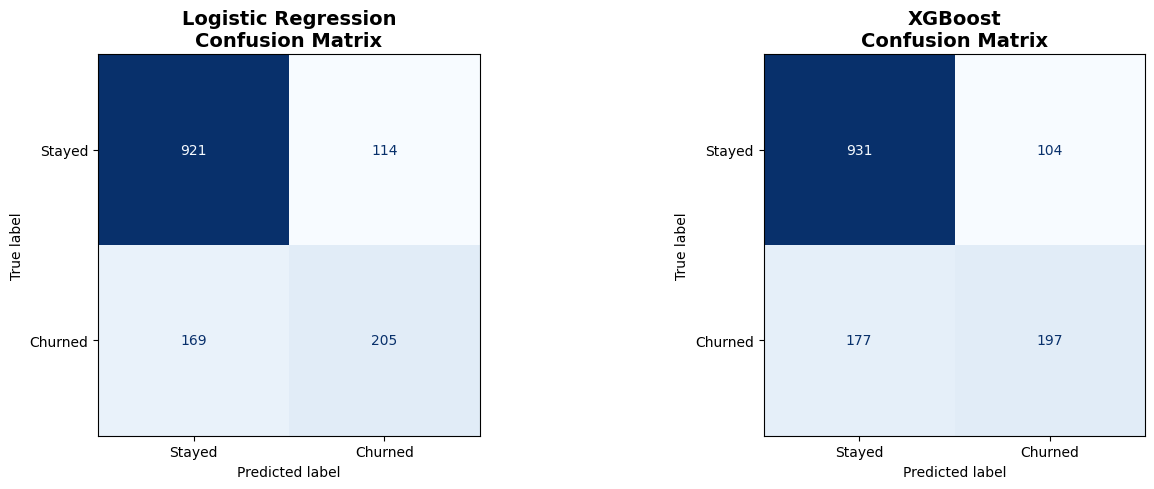

✅ Plot saved!


In [10]:
# PLOT: Confusion Matrices Side by Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title in zip(
    axes,
    [lr_pred, xgb_pred],
    ['Logistic Regression', 'XGBoost']
):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                   display_labels=['Stayed', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}\nConfusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../src/images/09_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

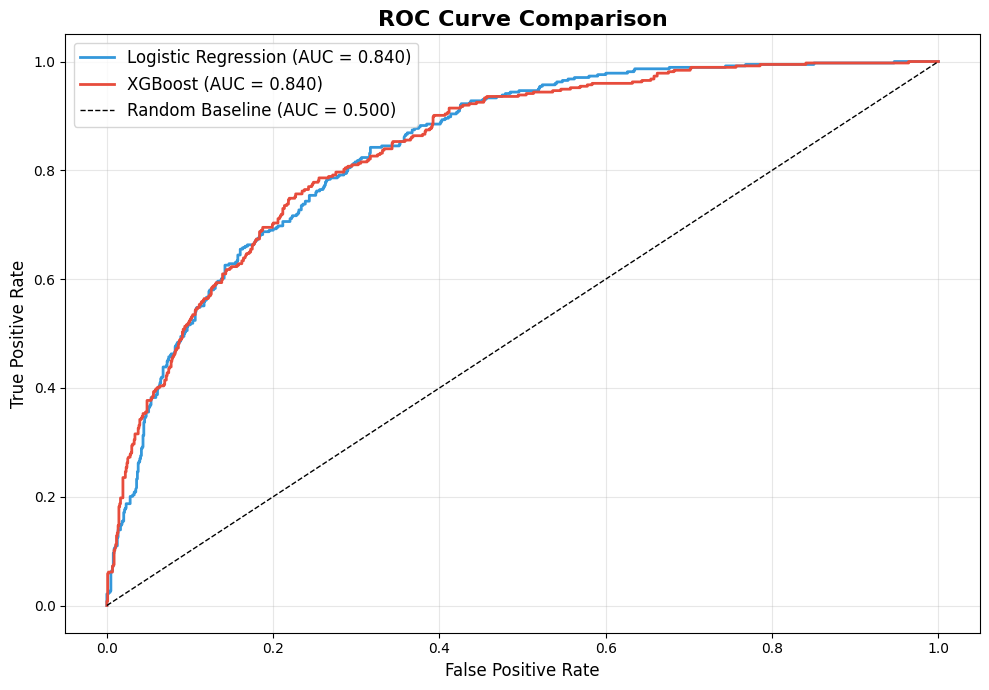

✅ Plot saved!


In [11]:
# PLOT: ROC Curves
fig, ax = plt.subplots(figsize=(10, 7))

# Logistic Regression ROC
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_pred_proba)
lr_auc = roc_auc_score(y_test, lr_pred_proba)
ax.plot(lr_fpr, lr_tpr, color='#3498db', linewidth=2,
        label=f'Logistic Regression (AUC = {lr_auc:.3f})')

# XGBoost ROC
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_pred_proba)
xgb_auc = roc_auc_score(y_test, xgb_pred_proba)
ax.plot(xgb_fpr, xgb_tpr, color='#e74c3c', linewidth=2,
        label=f'XGBoost (AUC = {xgb_auc:.3f})')

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline (AUC = 0.500)')

ax.set_title('ROC Curve Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../src/images/10_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

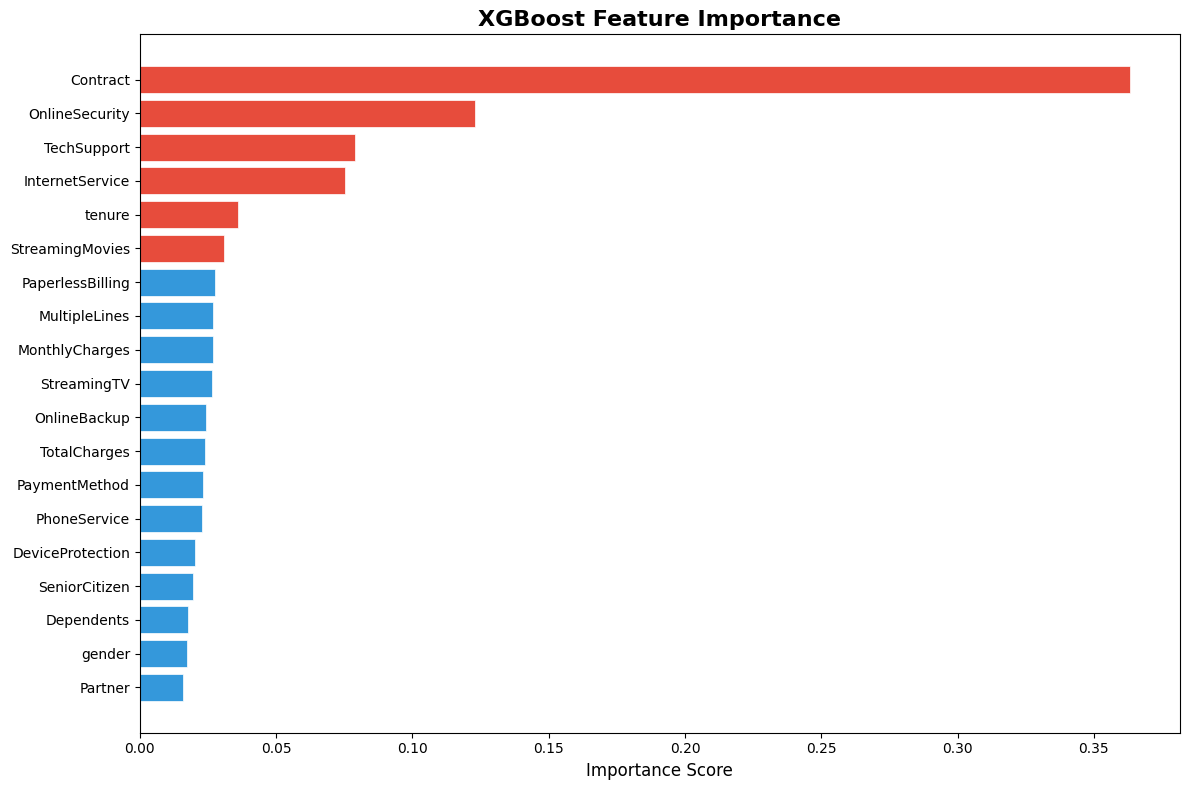

✅ Feature importance saved!


In [12]:
# PLOT: Feature Importance (XGBoost)
fig, ax = plt.subplots(figsize=(12, 8))

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

colors = ['#e74c3c' if x > feature_importance['Importance'].quantile(0.7) 
          else '#3498db' for x in feature_importance['Importance']]

ax.barh(feature_importance['Feature'], feature_importance['Importance'],
        color=colors, edgecolor='white', linewidth=0.5)

ax.set_title('XGBoost Feature Importance', fontsize=16, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)

plt.tight_layout()
plt.savefig('../src/images/11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Save feature importance
feature_importance.sort_values('Importance', ascending=False).to_csv(
    '../models/feature_importance.csv', index=False
)
print("✅ Feature importance saved!")

In [13]:
# SAVE BEST MODEL AND SCALER
import os
os.makedirs('../models', exist_ok=True)

# Save XGBoost (our best model)
joblib.dump(xgb_model, '../models/best_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(lr_model, '../models/logistic_regression.pkl')

print("✅ Models saved!")
print("  - ../models/best_model.pkl")
print("  - ../models/scaler.pkl")
print("  - ../models/logistic_regression.pkl")

✅ Models saved!
  - ../models/best_model.pkl
  - ../models/scaler.pkl
  - ../models/logistic_regression.pkl


In [14]:
# FINAL SUMMARY
print("=" * 60)
print("🎯 MODEL TRAINING COMPLETE!")
print("=" * 60)
print(results.to_string(index=False))
print(f"\n🏆 Best Model     : {best_model_name}")
print(f"📊 Best F1-Score  : {results['F1-Score'].max():.4f}")
print(f"📊 Best ROC-AUC   : {results['ROC-AUC'].max():.4f}")
print("\n✅ Move to Notebook 4: Predictions")

🎯 MODEL TRAINING COMPLETE!
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7991     0.6426  0.5481    0.5916   0.8403
            XGBoost    0.8006     0.6545  0.5267    0.5837   0.8404

🏆 Best Model     : Logistic Regression
📊 Best F1-Score  : 0.5916
📊 Best ROC-AUC   : 0.8404

✅ Move to Notebook 4: Predictions
